In [20]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from numpy.linalg import svd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch the dataset (ID 350 = Default of Credit Card Clients)
print("Fetching dataset from UCI Repository...")
taiwan_credit = fetch_ucirepo(id=350)
X_raw = taiwan_credit.data.features
y_raw = taiwan_credit.data.targets

# Combine into a single dataframe for processing
df = pd.concat([X_raw, y_raw], axis=1)
target_col = y_raw.columns[0]
feature_names = X_raw.columns.tolist()

print(f"Dataset Loaded: {df.shape[0]} rows, {len(feature_names)} features.")

Fetching dataset from UCI Repository...
Dataset Loaded: 30000 rows, 23 features.


In [21]:
# 1. Balance the dataset (Undersampling)
df_default = df[df[target_col] == 1]
df_no_default = df[df[target_col] == 0].sample(len(df_default), random_state=42)
df_balanced = pd.concat([df_default, df_no_default]).sample(frac=1, random_state=42)

# 2. Normalize features to [0, 1]
scaler = MinMaxScaler()
df_balanced[feature_names] = scaler.fit_transform(df_balanced[feature_names])

# 3. Calculate feature weights (Correlation with target)
weights = abs(df_balanced.corr()[target_col]).drop(target_col).values
weights = weights / (np.linalg.norm(weights) + 1e-8) # Normalize weights vector

# 4. Define bounds for the attack
bounds = [df_balanced[feature_names].min().values, df_balanced[feature_names].max().values]

print(f"Balanced Dataset Size: {len(df_balanced)} samples.")

Balanced Dataset Size: 13272 samples.


In [22]:
def clip(current, low_bound, up_bound):
    return torch.max(torch.min(current, torch.FloatTensor(up_bound)), torch.FloatTensor(low_bound))

def lowProFool(x, model, weights, bounds, maxiters, alpha, lambda_):
    r = Variable(torch.FloatTensor(1e-4 * np.ones(x.numpy().shape)), requires_grad=True)
    v = torch.FloatTensor(np.array(weights))
    output = model.forward(x + r)
    orig_pred = output.max(0, keepdim=True)[1].cpu().numpy()
    target_pred = np.abs(1 - orig_pred)
    target = Variable(torch.tensor([0., 1.] if target_pred == 1 else [1., 0.]))

    bce = nn.BCELoss()
    l2 = lambda v, r: torch.sqrt(torch.sum(torch.mul(v * r, v * r)))

    for i in range(maxiters):
        model.zero_grad()
        output = model.forward(x + r)
        loss = bce(output, target) + (lambda_ * l2(v, r))
        loss.backward(retain_graph=True)
        ri = -r.grad.data.cpu().numpy().copy() * alpha
        r = Variable(torch.FloatTensor(r.detach().cpu().numpy() + ri), requires_grad=True)

    best_pert_x = clip(x + r, bounds[0], bounds[1])
    output_pred = model.forward(best_pert_x).max(0, keepdim=True)[1].cpu().numpy()
    return orig_pred[0], output_pred[0], best_pert_x.detach().cpu().numpy()

In [27]:
class TaiwanNet(nn.Module):
    def __init__(self, D_in):
        super(TaiwanNet, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(D_in, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 2), nn.Softmax(dim=0)
        )
    def forward(self, x): return self.layer(x)

# Prepare PyTorch Tensors
X_tensor = torch.FloatTensor(df_balanced[feature_names].values)
y_tensor = torch.nn.functional.one_hot(torch.LongTensor(df_balanced[target_col].values)).float()
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)

model = TaiwanNet(len(feature_names))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print("Training model...")
for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()
print("Training Complete.")

Training model...
Training Complete.


In [34]:

test_samples = X_test[:2000]
alpha_for_tsne = 0.05
lambdas = [0.0, 1.0, 5.0]

# Baseline SVD
_, s_orig, _ = svd(test_samples.numpy(), full_matrices=False)
svd_lambda_spectrums = { "Original": s_orig }
tsne_lambda_data = [pd.DataFrame(test_samples.numpy(), columns=feature_names).assign(Type='Original')]


In [35]:

# Define the range of alpha values to test for the grid search
# (lambdas are already defined in CELL 5)
alphas_to_test = [0.01, 0.05, 0.1, 0.2]

results_list = []
all_adv_tsne_data = [] # Initialize list to store adversarial samples for t-SNE

print("Running LowProFool Parameter Grid Search for Attack Success and SVD Damage...")

# Ensure test_samples is a tensor for iteration
if not isinstance(test_samples, torch.Tensor):
    test_samples = torch.FloatTensor(test_samples)

for l in tqdm(lambdas, desc="Lambdas"): # Use 'lambdas' from CELL 5
    for a in tqdm(alphas_to_test, desc=f"  Lambda={l}, Alphas"):
        adv_preds = []
        orig_preds = []
        adv_samples_for_svd = []

        for x in test_samples:
            orig_pred, adv_pred, x_adv = lowProFool(x, model, weights, bounds, 300, a, l)
            orig_preds.append(orig_pred)
            adv_preds.append(adv_pred)
            adv_samples_for_svd.append(x_adv) # Collect adversarial samples

        # Calculate Attack Success Rate
        success_rate = np.mean(np.array(orig_preds) != np.array(adv_preds))

        # Calculate SVD Structural Damage
        adv_matrix_current_params = np.array(adv_samples_for_svd)
        _, s_adv_current_params, _ = svd(adv_matrix_current_params, full_matrices=False)

        # Use a simple metric for SVD damage: mean absolute difference of singular values
        # Ensure s_adv_current_params and s_orig have the same length for comparison
        min_len = min(len(s_orig), len(s_adv_current_params))
        svd_damage = np.mean(np.abs(s_orig[:min_len] - s_adv_current_params[:min_len]))

        results_list.append({
            'lambda': l,
            'alpha': a,
            'success': success_rate,
            'svd': svd_damage
        })

        # Store adversarial samples for t-SNE for this combination
        all_adv_tsne_data.append({
            'lambda': l,
            'alpha': a,
            'adv_matrix': adv_matrix_current_params # Store the numpy array of adversarial samples
        })

results = pd.DataFrame(results_list)
print("Grid Search Complete. Results DataFrame created.")
display(results)

Running LowProFool Parameter Grid Search for Attack Success and SVD Damage...


Lambdas: 100%|██████████| 3/3 [1:33:22<00:00, 1867.39s/it]

Grid Search Complete. Results DataFrame created.


,lambda,alpha,success,svd
0,0.0,0.01,1.0000,1.177659
1,0.0,0.05,1.0000,2.228212
2,0.0,0.10,1.0000,2.707323
3,0.0,0.20,1.0000,3.150348
4,1.0,0.01,0.8740,0.450824
5,1.0,0.05,0.8640,1.391403
6,1.0,0.10,0.9010,1.868480
7,1.0,0.20,0.8860,2.177650
8,5.0,0.01,0.6510,0.832995
9,5.0,0.05,0.7100,1.287194


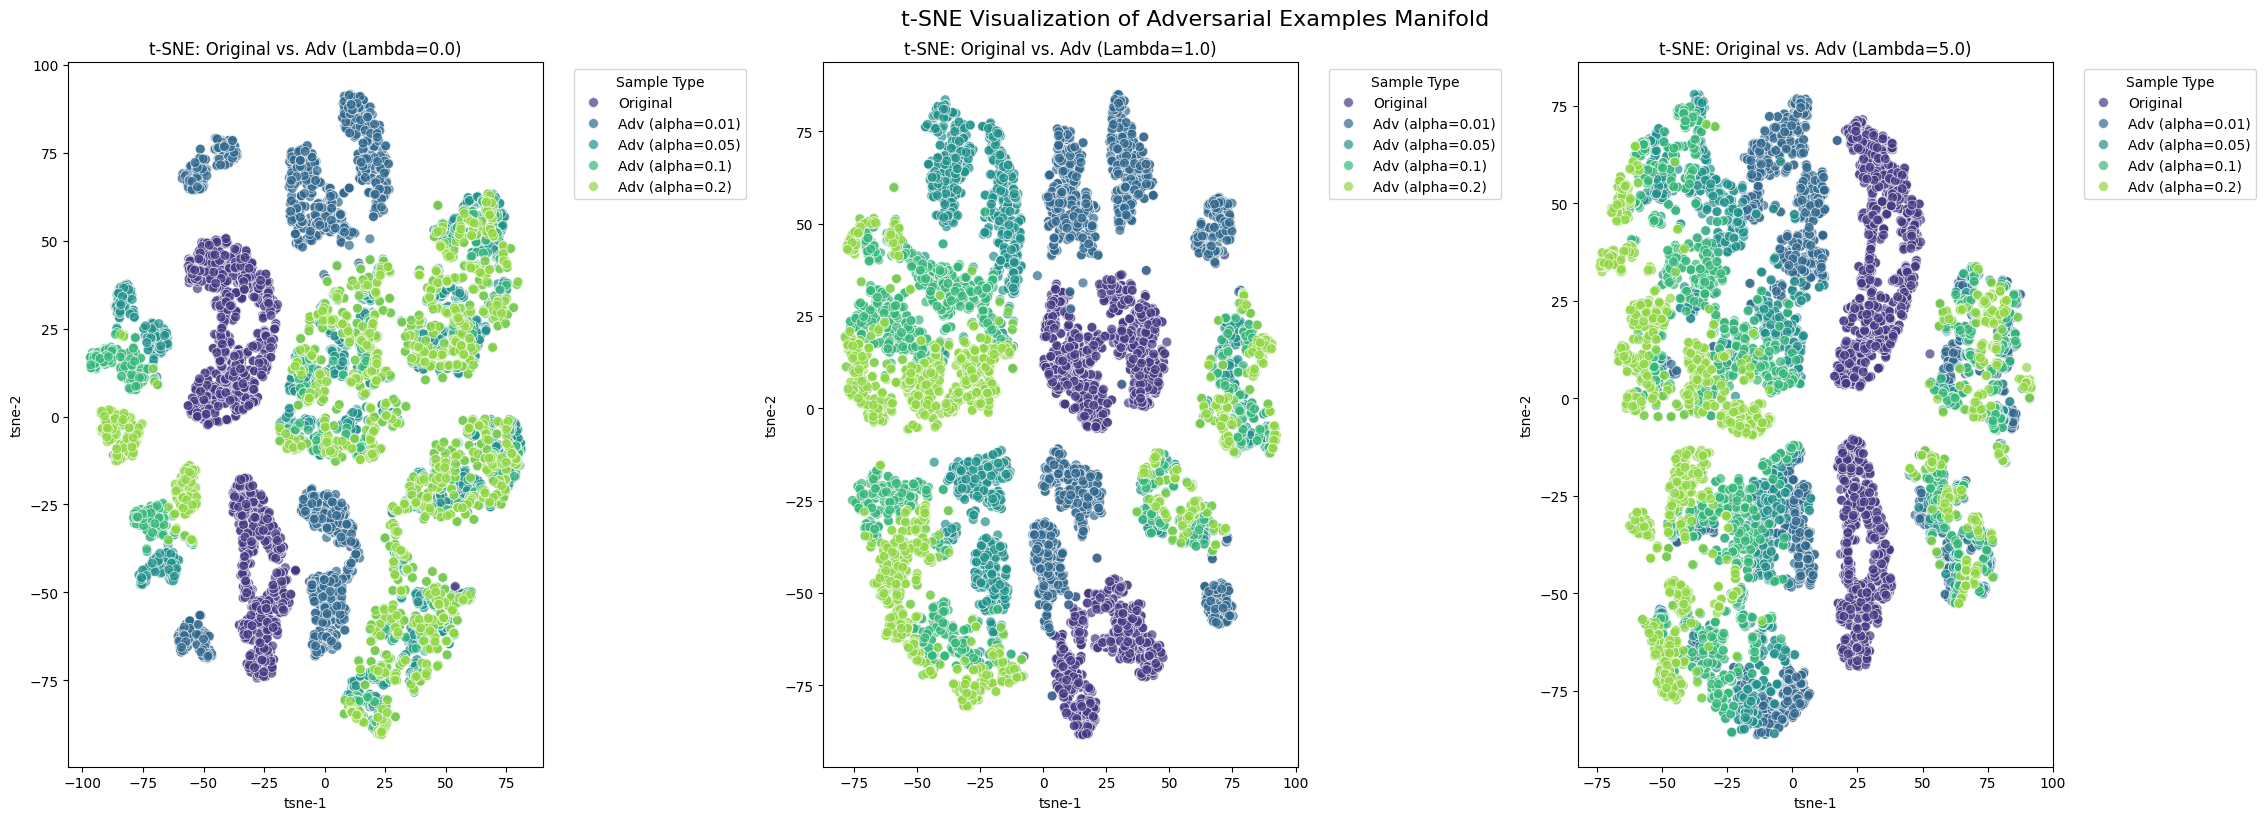

In [36]:
# Visualize t-SNE for all Alpha and Lambda combinations
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare original data for t-SNE comparison
original_df = pd.DataFrame(test_samples.numpy(), columns=feature_names).assign(Type='Original')

# Define the number of unique lambda values to determine subplot grid size
unique_lambdas = sorted(list(set([d['lambda'] for d in all_adv_tsne_data])))
num_lambdas = len(unique_lambdas)

# Create a figure with subplots for each lambda
plt.figure(figsize=(8 * num_lambdas, 8))

plot_idx = 1
for l_val in unique_lambdas:
    # Filter adversarial data for the current lambda
    lambda_specific_adv_data = [d for d in all_adv_tsne_data if d['lambda'] == l_val]

    # Combine original and adversarial data for this specific lambda for t-SNE
    tsne_combined_data = [original_df]
    for data_item in lambda_specific_adv_data:
        alpha_val = data_item['alpha']
        adv_matrix = data_item['adv_matrix']
        tsne_combined_data.append(pd.DataFrame(adv_matrix, columns=feature_names).assign(Type=f"Adv (alpha={alpha_val})"))

    combined_for_tsne_df = pd.concat(tsne_combined_data)

    # Perform t-SNE. Use a consistent perplexity and random_state.
    data_to_tsne = combined_for_tsne_df.drop('Type', axis=1).astype(np.float32)
    # It's crucial to ensure `data_to_tsne` has enough samples for `perplexity`
    # If it's small, adjust perplexity or catch error. For 200 samples, 30 is fine.
    res = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(data_to_tsne)
    combined_for_tsne_df['tsne-1'], combined_for_tsne_df['tsne-2'] = res[:, 0], res[:, 1]

    # Create subplot
    plt.subplot(1, num_lambdas, plot_idx)
    sns.scatterplot(data=combined_for_tsne_df, x='tsne-1', y='tsne-2', hue='Type', palette='viridis', alpha=0.7, s=50)
    plt.title(f"t-SNE: Original vs. Adv (Lambda={l_val})")
    plt.legend(title='Sample Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    plot_idx += 1

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to prevent legend overlap
plt.suptitle('t-SNE Visualization of Adversarial Examples Manifold', y=1.02, fontsize=16)
plt.show()


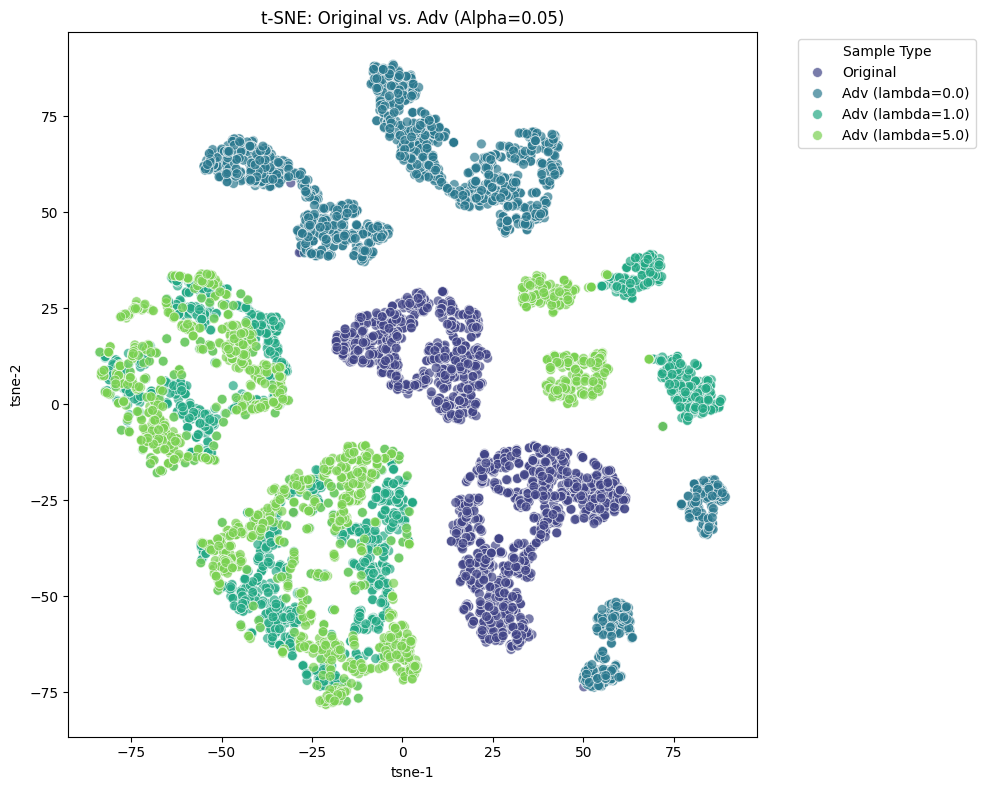

In [37]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Define a fixed alpha value for this visualization
fixed_alpha = 0.05

# 2. Filter all_adv_tsne_data to include only the adversarial samples corresponding to this fixed_alpha
alpha_specific_adv_data = [d for d in all_adv_tsne_data if d['alpha'] == fixed_alpha]

# 3. Create a list, tsne_data_for_fixed_alpha, by combining the original_df with the filtered adversarial samples
tsne_data_for_fixed_alpha = [original_df]
for data_item in alpha_specific_adv_data:
    lambda_val = data_item['lambda']
    adv_matrix = data_item['adv_matrix']
    tsne_data_for_fixed_alpha.append(pd.DataFrame(adv_matrix, columns=feature_names).assign(Type=f"Adv (lambda={lambda_val})"))

# 4. Concatenate tsne_data_for_fixed_alpha into a single DataFrame
combined_for_tsne_fixed_alpha_df = pd.concat(tsne_data_for_fixed_alpha)

# 5. Perform t-SNE on the combined DataFrame
data_to_tsne_fixed_alpha = combined_for_tsne_fixed_alpha_df.drop('Type', axis=1).astype(np.float32)
res_fixed_alpha = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(data_to_tsne_fixed_alpha)
combined_for_tsne_fixed_alpha_df['tsne-1'], combined_for_tsne_fixed_alpha_df['tsne-2'] = res_fixed_alpha[:, 0], res_fixed_alpha[:, 1]

# 6-8. Create a scatter plot with appropriate labels, title, and legend
plt.figure(figsize=(10, 8))
sns.scatterplot(data=combined_for_tsne_fixed_alpha_df, x='tsne-1', y='tsne-2', hue='Type', palette='viridis', alpha=0.7, s=50)
plt.title(f"t-SNE: Original vs. Adv (Alpha={fixed_alpha})")
plt.legend(title='Sample Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 9. Display the plot
plt.show()

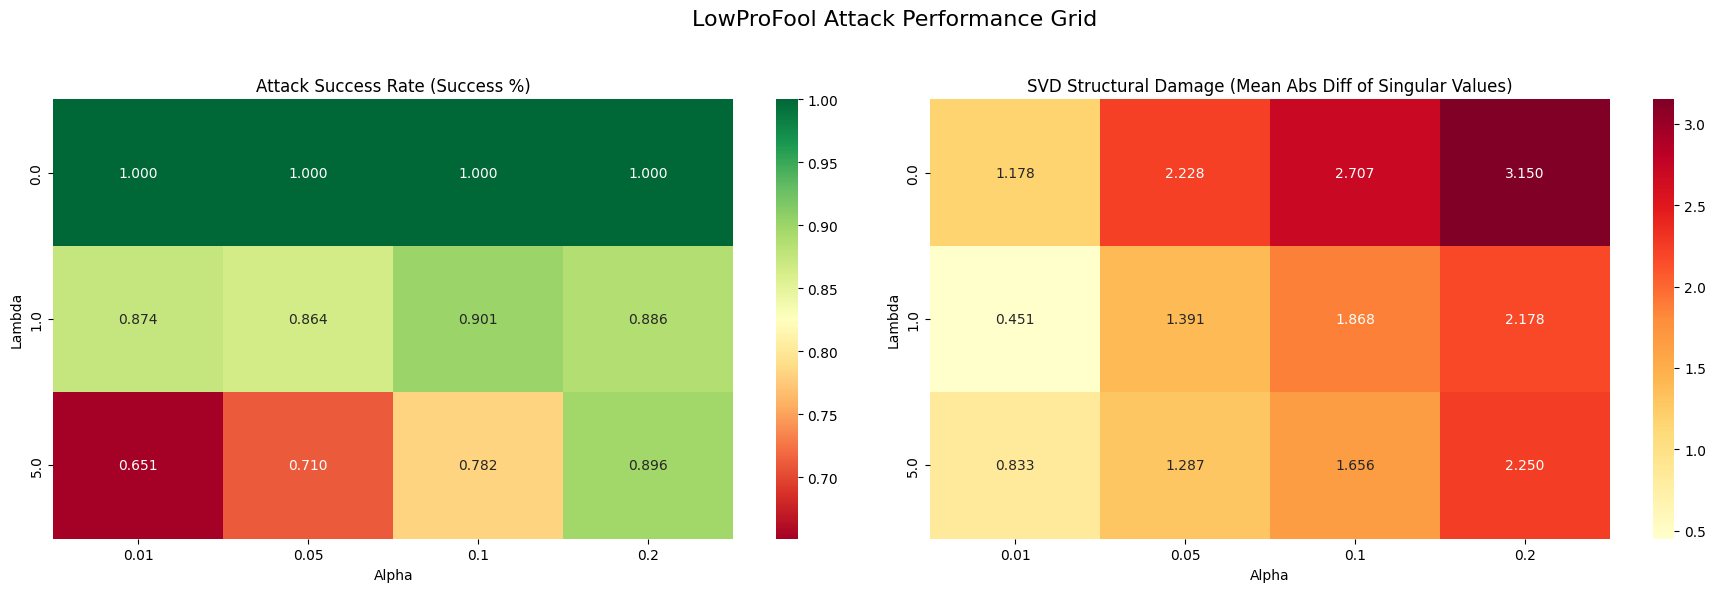

In [38]:
# --- Attack Success Rate and SVD Structural Damage Heatmaps ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure results DataFrame exists (it should from the previous cell)
if 'results' in locals() and isinstance(results, pd.DataFrame):
    res_df = results
else:
    print("Error: 'results' DataFrame not found. Please run the parameter grid search cell first.")
    res_df = pd.DataFrame() # Create an empty DataFrame to avoid further errors

if not res_df.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Plot Attack Success Rate
    success_pivot = res_df.pivot(index='lambda', columns='alpha', values='success')
    sns.heatmap(success_pivot, annot=True, fmt=".3f", cmap='RdYlGn', ax=ax1)
    ax1.set_title("Attack Success Rate (Success %)")
    ax1.set_xlabel("Alpha")
    ax1.set_ylabel("Lambda")

    # Plot SVD Structural Damage
    svd_pivot = res_df.pivot(index='lambda', columns='alpha', values='svd')
    sns.heatmap(svd_pivot, annot=True, fmt=".3f", cmap='YlOrRd', ax=ax2)
    ax2.set_title("SVD Structural Damage (Mean Abs Diff of Singular Values)")
    ax2.set_xlabel("Alpha")
    ax2.set_ylabel("Lambda")

    plt.suptitle("LowProFool Attack Performance Grid", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print("Cannot generate heatmaps: 'results' DataFrame is empty.")

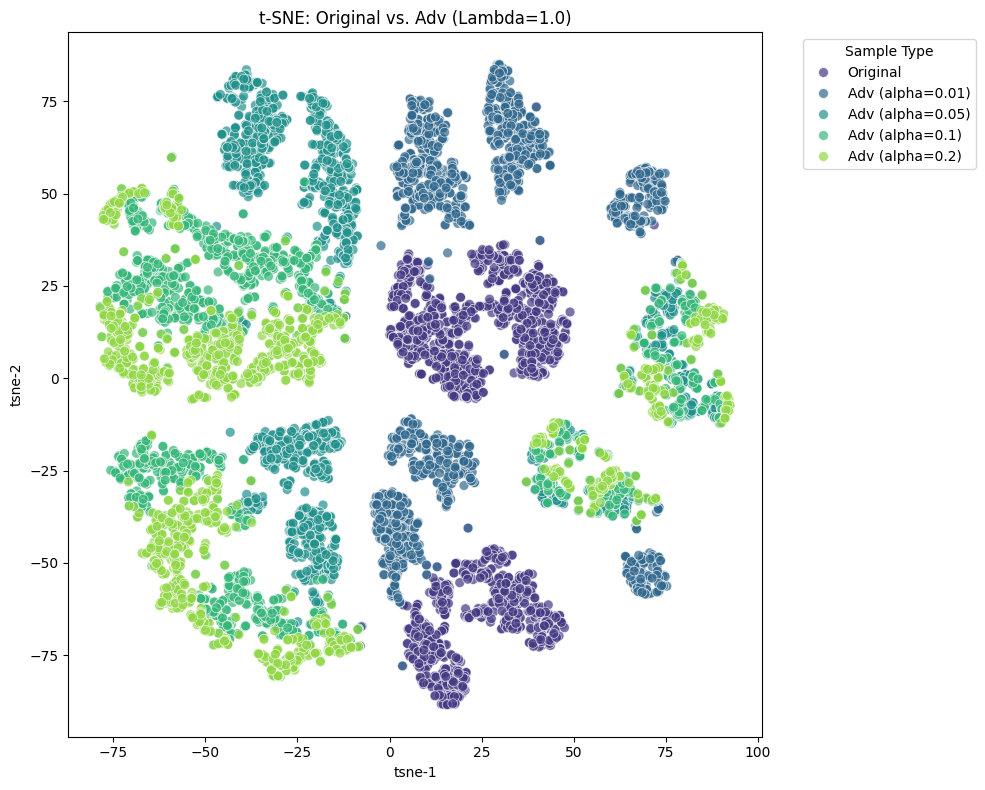

In [39]:
# --- NEW CELL: Visualize t-SNE for Alpha variations with a fixed Lambda ---
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Define a fixed lambda value for this visualization
fixed_lambda = 1.0 # You can choose a different lambda value if desired

# 2. Filter all_adv_tsne_data to include only the adversarial samples corresponding to this fixed_lambda
lambda_specific_adv_data_for_alpha = [d for d in all_adv_tsne_data if d['lambda'] == fixed_lambda]

# 3. Create a list, tsne_data_for_fixed_lambda, by combining the original_df with the filtered adversarial samples
tsne_data_for_fixed_lambda = [original_df]
for data_item in lambda_specific_adv_data_for_alpha:
    alpha_val = data_item['alpha']
    adv_matrix = data_item['adv_matrix']
    tsne_data_for_fixed_lambda.append(pd.DataFrame(adv_matrix, columns=feature_names).assign(Type=f"Adv (alpha={alpha_val})"))

# 4. Concatenate tsne_data_for_fixed_lambda into a single DataFrame
combined_for_tsne_fixed_lambda_df = pd.concat(tsne_data_for_fixed_lambda)

# 5. Perform t-SNE on the combined DataFrame
data_to_tsne_fixed_lambda = combined_for_tsne_fixed_lambda_df.drop('Type', axis=1).astype(np.float32)
res_fixed_lambda = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(data_to_tsne_fixed_lambda)
combined_for_tsne_fixed_lambda_df['tsne-1'], combined_for_tsne_fixed_lambda_df['tsne-2'] = res_fixed_lambda[:, 0], res_fixed_lambda[:, 1]

# 6-8. Create a scatter plot with appropriate labels, title, and legend
plt.figure(figsize=(10, 8))
sns.scatterplot(data=combined_for_tsne_fixed_lambda_df, x='tsne-1', y='tsne-2', hue='Type', palette='viridis', alpha=0.7, s=50)
plt.title(f"t-SNE: Original vs. Adv (Lambda={fixed_lambda})")
plt.legend(title='Sample Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# 9. Display the plot
plt.show()

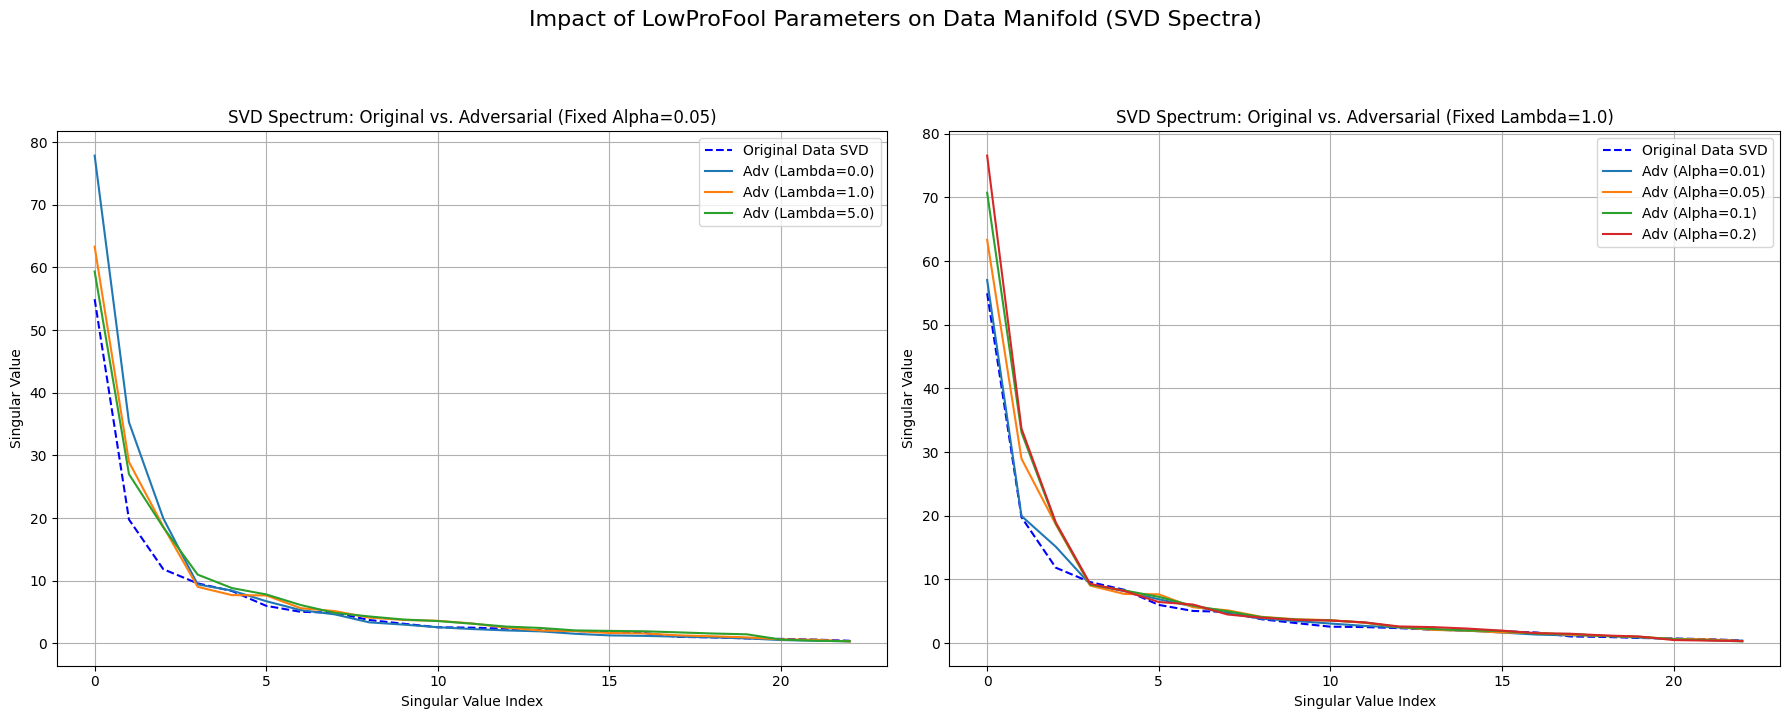

In [40]:
# --- SVD Spectrum Plots for Lambda and Alpha Variations ---
import matplotlib.pyplot as plt
import numpy as np
from numpy.linalg import svd
import pandas as pd

plt.figure(figsize=(18, 7))

# --- Plot 1: SVD Spectrum Changes for varying Lambda (fixed alpha) ---
plt.subplot(1, 2, 1)
plt.plot(s_orig, label='Original Data SVD', color='blue', linestyle='--')

# Filter for adv_matrix when alpha is fixed (alpha_for_tsne = 0.05)
lambda_svd_data = [d for d in all_adv_tsne_data if d['alpha'] == alpha_for_tsne]

for data_item in lambda_svd_data:
    l_val = data_item['lambda']
    adv_matrix_l = data_item['adv_matrix']
    _, s_adv_l, _ = svd(adv_matrix_l, full_matrices=False)
    plt.plot(s_adv_l, label=f'Adv (Lambda={l_val})')

plt.title(f"SVD Spectrum: Original vs. Adversarial (Fixed Alpha={alpha_for_tsne})")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.legend()
plt.grid(True)

# --- Plot 2: SVD Spectrum Changes for varying Alpha (fixed lambda) ---
plt.subplot(1, 2, 2)
fixed_lambda_for_alpha_svd = 1.0 # Define a fixed lambda for this plot
plt.plot(s_orig, label='Original Data SVD', color='blue', linestyle='--')

# Filter for adv_matrix when lambda is fixed
alpha_svd_data = [d for d in all_adv_tsne_data if d['lambda'] == fixed_lambda_for_alpha_svd]

for data_item in alpha_svd_data:
    a_val = data_item['alpha']
    adv_matrix_a = data_item['adv_matrix']
    _, s_adv_a, _ = svd(adv_matrix_a, full_matrices=False)
    plt.plot(s_adv_a, label=f'Adv (Alpha={a_val})')

plt.title(f"SVD Spectrum: Original vs. Adversarial (Fixed Lambda={fixed_lambda_for_alpha_svd})")
plt.xlabel("Singular Value Index")
plt.ylabel("Singular Value")
plt.legend()
plt.grid(True)

plt.suptitle("Impact of LowProFool Parameters on Data Manifold (SVD Spectra)", fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()